In [53]:
!pip install ucimlrepo shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_score
)

In [54]:
# Library imports moved to top cell.

In [39]:
# fetch breast cancer data set
breast_cancer_wisconsin = fetch_ucirepo(id=17)

In [40]:
#Convert dataset to dataframe
X = breast_cancer_wisconsin.data.features
Y = breast_cancer_wisconsin.data.targets

# Combine into one data frame
breast_cancer_dataset = pd.concat([X,Y], axis=1)

breast_cancer_dataset.info()

#Describe Dataset
breast_cancer_dataset.describe()

#Check for Missing Values per column
#breast_cancer_dataset.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   radius1             569 non-null    float64
 1   texture1            569 non-null    float64
 2   perimeter1          569 non-null    float64
 3   area1               569 non-null    float64
 4   smoothness1         569 non-null    float64
 5   compactness1        569 non-null    float64
 6   concavity1          569 non-null    float64
 7   concave_points1     569 non-null    float64
 8   symmetry1           569 non-null    float64
 9   fractal_dimension1  569 non-null    float64
 10  radius2             569 non-null    float64
 11  texture2            569 non-null    float64
 12  perimeter2          569 non-null    float64
 13  area2               569 non-null    float64
 14  smoothness2         569 non-null    float64
 15  compactness2        569 non-null    float64
 16  concavit

,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Data Preparation

In [41]:
# Split Dataset to Train-Test Split
from sklearn.model_selection import train_test_split

#Combined dataSet
X = breast_cancer_dataset.drop('Diagnosis', axis=1)
Y = breast_cancer_dataset['Diagnosis']

# Splitting X and Y into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Display the shapes to confirm
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (455, 30)
X_test shape: (114, 30)


Machine Learning Modelling

Zero R

In [42]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Initialize and train the ZeroR classifier
# It predicts the most frequent class ('B' in this dataset)
zero_r = DummyClassifier(strategy="most_frequent")
zero_r.fit(X_train, Y_train)

# Make predictions
y_pred_zero_r = zero_r.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(Y_test, y_pred_zero_r)
print(f"ZeroR Baseline Accuracy: {accuracy:.4f}")

ZeroR Baseline Accuracy: 0.6228


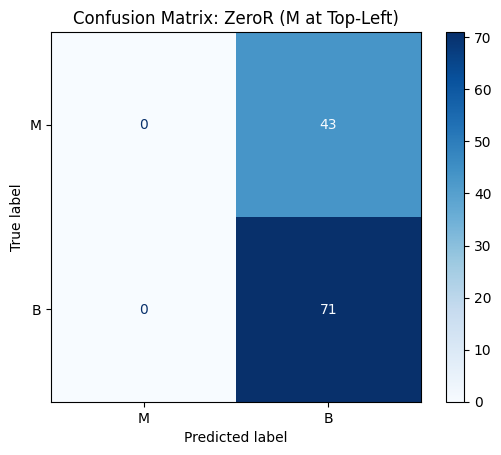

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Updated labels order: 'M' first for TP at top-left
labels = ['M', 'B']
cm = confusion_matrix(Y_test, y_pred_zero_r, labels=labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: ZeroR (M at Top-Left)')
plt.show()

In [44]:
import numpy as np
from sklearn.metrics import accuracy_score

def train_oner_error_based(X, y):
    best_feature = None
    best_threshold = None
    best_direction = None
    min_error = float('inf')
    n_samples = len(y)

    for feature in X.columns:
        # Finding optimal threshold by minimizing error
        thresholds = np.unique(X[feature])
        for threshold in thresholds:
            for direction in ['less', 'greater']:
                if direction == 'less':
                    predictions = np.where(X[feature] <= threshold, 'M', 'B')
                else:
                    predictions = np.where(X[feature] > threshold, 'M', 'B')

                # Error is the number of mismatches
                error = np.sum(predictions != y)

                if error < min_error:
                    min_error = error
                    best_feature = feature
                    best_threshold = threshold
                    best_direction = direction

    return best_feature, best_threshold, best_direction, min_error / n_samples

# Train Error-based OneR
feature, threshold, direction, train_error = train_oner_error_based(X_train, Y_train)

# Predict on test set
if direction == 'less':
    y_pred_oner = np.where(X_test[feature] <= threshold, 'M', 'B')
else:
    y_pred_oner = np.where(X_test[feature] > threshold, 'M', 'B')

oner_accuracy = accuracy_score(Y_test, y_pred_oner)
print(f"OneR Best Feature (Min Error): {feature}")
print(f"Training Error Rate: {train_error:.4f}")
print(f"OneR Test Accuracy: {oner_accuracy:.4f}")

OneR Best Feature (Min Error): concave_points1
Training Error Rate: 0.0791
OneR Test Accuracy: 0.8860


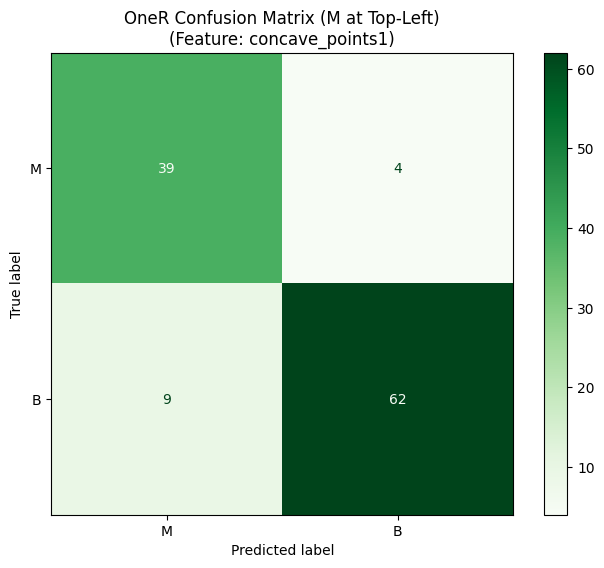

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Updated labels order: 'M' first for TP at top-left
labels = ['M', 'B']
cm_oner = confusion_matrix(Y_test, y_pred_oner, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_oner, display_labels=labels)
disp.plot(cmap=plt.cm.Greens, ax=ax)
ax.set_title(f'OneR Confusion Matrix (M at Top-Left)\n(Feature: {feature})')
plt.show()

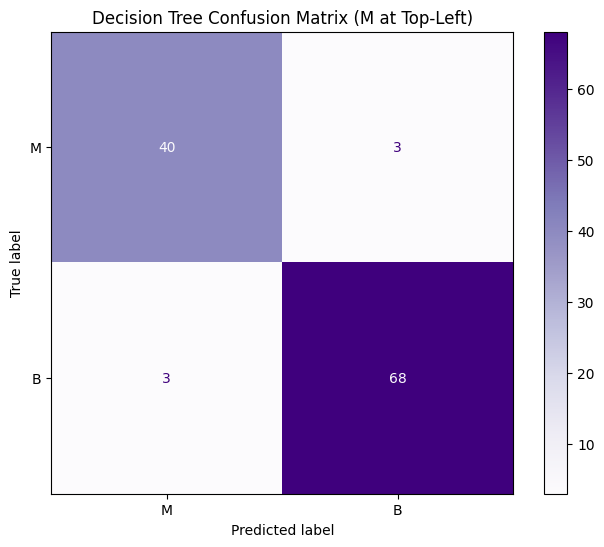

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# Updated labels order: 'M' first for TP at top-left
labels = ['M', 'B']
cm_dt = confusion_matrix(Y_test, y_pred_dt, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=labels)
disp.plot(cmap=plt.cm.Purples, ax=ax)
ax.set_title('Decision Tree Confusion Matrix (M at Top-Left)')
plt.show()

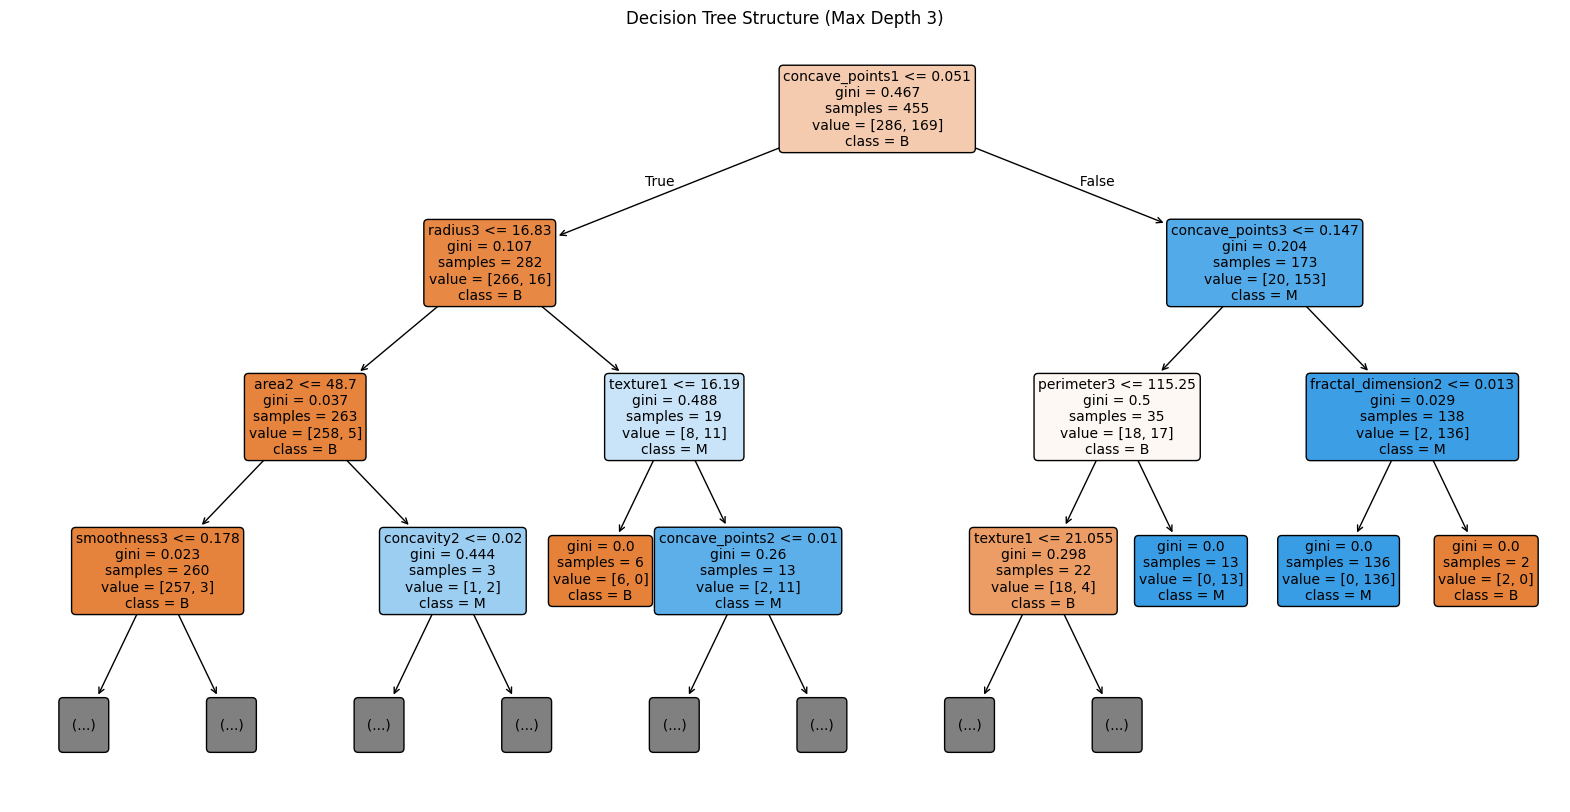

In [47]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 2. Decision Tree Structure Visualization
plt.figure(figsize=(20, 10))
plot_tree(dt_clf,
          feature_names=X.columns.tolist(),
          class_names=['B', 'M'],
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Limited depth for readability
plt.title('Decision Tree Structure (Max Depth 3)')
plt.show()

In [48]:
from sklearn.metrics import recall_score, precision_score, confusion_matrix

# Calculate metrics using 'M' as the positive class
# Sensitivity is the same as Recall for the positive class
sensitivity = recall_score(Y_test, y_pred_dt, pos_label='M')
precision = precision_score(Y_test, y_pred_dt, pos_label='M')

# Specificity is Recall for the negative class ('B')
specificity = recall_score(Y_test, y_pred_dt, pos_label='B')

# Recall (duplicate of sensitivity for clarity)
recall = sensitivity

print(f"Decision Tree Metrics (Positive Class: M):")
print(f"- Sensitivity (Recall): {sensitivity:.4f}")
print(f"- Specificity: {specificity:.4f}")
print(f"- Precision: {precision:.4f}")
print(f"- Recall: {recall:.4f}")

Decision Tree Metrics (Positive Class: M):
- Sensitivity (Recall): 0.9302
- Specificity: 0.9577
- Precision: 0.9302
- Recall: 0.9302


# 1. Naive Bayes Model

Naive Bayes (Gaussian) Metrics:
- Sensitivity: 0.9302
- Specificity: 1.0000
- Precision: 1.0000
- Recall: 0.9302


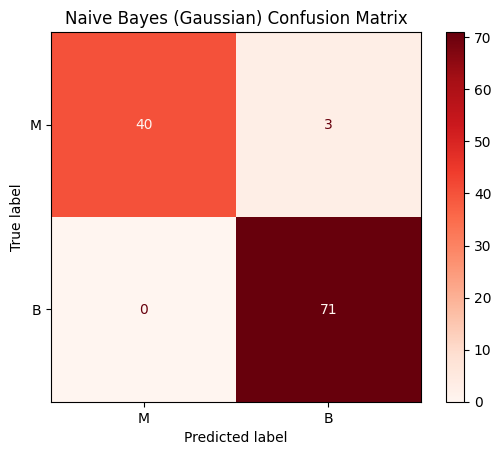

In [59]:
# Train Model using Gaussian Naive Bayes
nb_clf = GaussianNB()
nb_clf.fit(X_train, Y_train)
y_pred_nb = nb_clf.predict(X_test)

# Metrics (Positive Class: M)
labels = ['M', 'B']
sensitivity_nb = recall_score(Y_test, y_pred_nb, pos_label='M')
specificity_nb = recall_score(Y_test, y_pred_nb, pos_label='B')
precision_nb = precision_score(Y_test, y_pred_nb, pos_label='M')
recall_nb = sensitivity_nb

print(f"Naive Bayes (Gaussian) Metrics:\n- Sensitivity: {sensitivity_nb:.4f}\n- Specificity: {specificity_nb:.4f}\n- Precision: {precision_nb:.4f}\n- Recall: {recall_nb:.4f}")

# Confusion Matrix
cm_nb = confusion_matrix(Y_test, y_pred_nb, labels=labels)
disp = ConfusionMatrixDisplay(cm_nb, display_labels=labels)
disp.plot(cmap=plt.cm.Reds)
plt.title('Naive Bayes (Gaussian) Confusion Matrix')
plt.show()

# 2. Logistic Regression Model

Logistic Regression Metrics:
- Sensitivity: 0.9535
- Specificity: 0.9859
- Precision: 0.9762


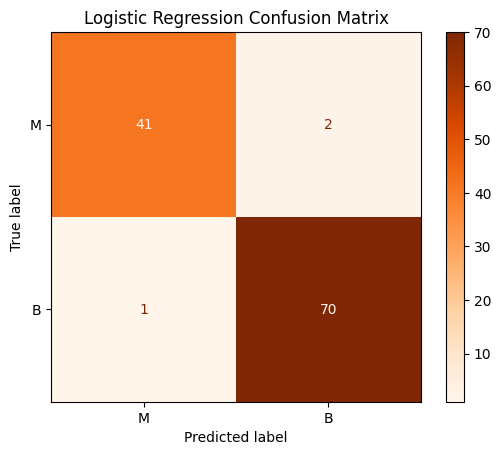

In [56]:
# Scale data for Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Model
lr_clf = LogisticRegression(max_iter=10000)
lr_clf.fit(X_train_scaled, Y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)

# Metrics
labels = ['M', 'B']
sensitivity_lr = recall_score(Y_test, y_pred_lr, pos_label='M')
specificity_lr = recall_score(Y_test, y_pred_lr, pos_label='B')
precision_lr = precision_score(Y_test, y_pred_lr, pos_label='M')

print(f"Logistic Regression Metrics:\n- Sensitivity: {sensitivity_lr:.4f}\n- Specificity: {specificity_lr:.4f}\n- Precision: {precision_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(Y_test, y_pred_lr, labels=labels)
ConfusionMatrixDisplay(cm_lr, display_labels=labels).plot(cmap=plt.cm.Oranges)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# 3. K-Nearest Neighbors (KNN)

KNN Metrics:
- Sensitivity: 0.9302
- Specificity: 0.9577
- Precision: 0.9302


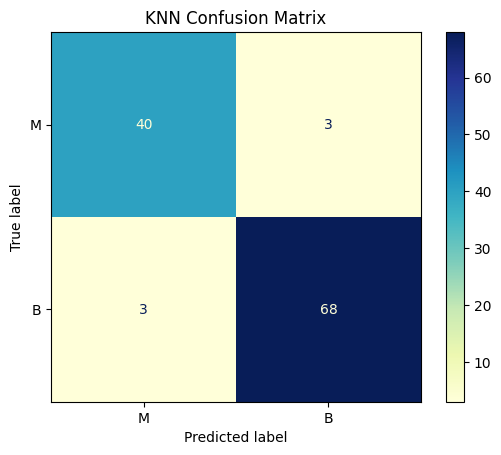

In [57]:
# Train Model
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, Y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)

# Metrics
labels = ['M', 'B']
sensitivity_knn = recall_score(Y_test, y_pred_knn, pos_label='M')
specificity_knn = recall_score(Y_test, y_pred_knn, pos_label='B')
precision_knn = precision_score(Y_test, y_pred_knn, pos_label='M')

print(f"KNN Metrics:\n- Sensitivity: {sensitivity_knn:.4f}\n- Specificity: {specificity_knn:.4f}\n- Precision: {precision_knn:.4f}")

# Confusion Matrix
cm_knn = confusion_matrix(Y_test, y_pred_knn, labels=labels)
ConfusionMatrixDisplay(cm_knn, display_labels=labels).plot(cmap=plt.cm.YlGnBu)
plt.title('KNN Confusion Matrix')
plt.show()

# 4. SHAP Feature Importance Analysis

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


  0%|          | 0/114 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:27

SHAP Summary Plot for Naive Bayes Classifier:


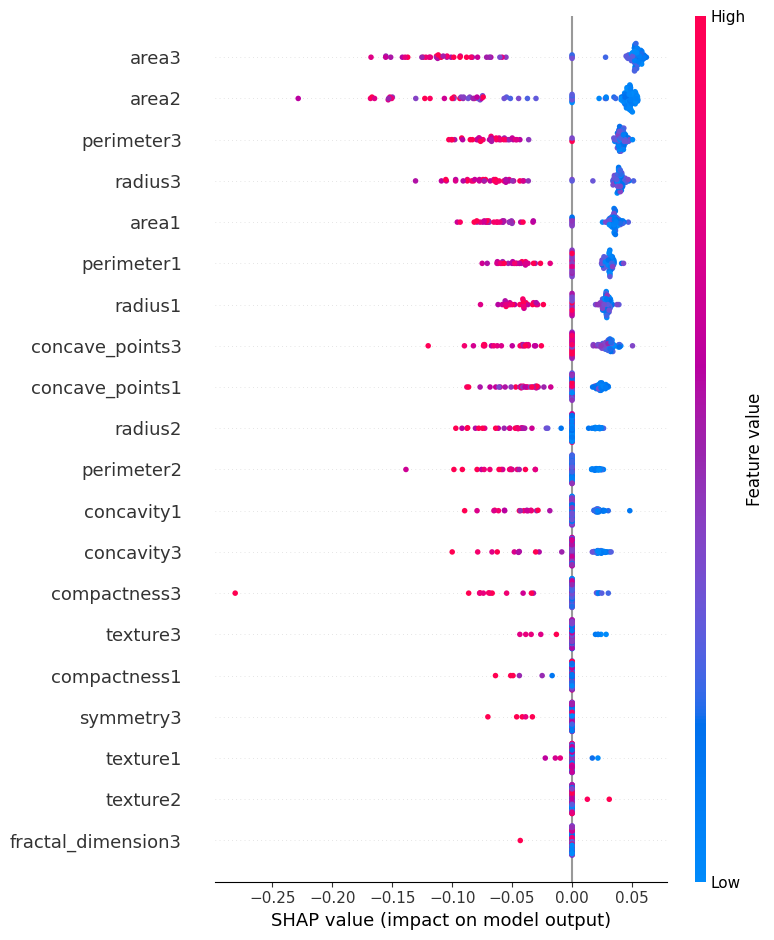

In [60]:
# Using Naive Bayes for SHAP
# KernelExplainer is used for models that don't have a specific Tree or Linear explainer
# We use a small sample (medoid or mean) or just a subset for speed if needed,
# but here we use the training data as background.

# Define the prediction function for SHAP (probability of class 'M')
def predict_nb_proba(data):
    return nb_clf.predict_proba(data)[:, 0] # Index 0 corresponds to 'M' based on label ordering

# Create the explainer using a summary of the training data as background
# Using 10 samples as background to speed up the KernelExplainer
background = shap.kmeans(X_train, 10)
explainer_nb = shap.KernelExplainer(predict_nb_proba, background)

# Calculate SHAP values for the test set
shap_values_nb = explainer_nb.shap_values(X_test)

# SHAP Summary Plot for Naive Bayes
print("SHAP Summary Plot for Naive Bayes Classifier:")
shap.summary_plot(shap_values_nb, X_test, feature_names=X.columns)

# Logistic Regression Classifier

Logistic Regression Metrics (Positive: M):
- Accuracy: 0.9737
- Sensitivity (Recall): 0.9535
- Specificity: 0.9859
- Precision: 0.9762


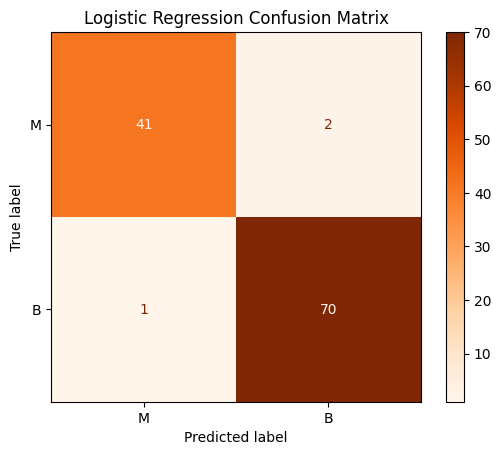

In [61]:
# Train Logistic Regression
# Data scaling was performed in a previous step
lr_clf = LogisticRegression(max_iter=10000)
lr_clf.fit(X_train_scaled, Y_train)
y_pred_lr = lr_clf.predict(X_test_scaled)

# Calculate Metrics
labels = ['M', 'B']
sensitivity_lr = recall_score(Y_test, y_pred_lr, pos_label='M')
specificity_lr = recall_score(Y_test, y_pred_lr, pos_label='B')
precision_lr = precision_score(Y_test, y_pred_lr, pos_label='M')
recall_lr = sensitivity_lr
accuracy_lr = accuracy_score(Y_test, y_pred_lr)

print(f"Logistic Regression Metrics (Positive: M):")
print(f"- Accuracy: {accuracy_lr:.4f}")
print(f"- Sensitivity (Recall): {sensitivity_lr:.4f}")
print(f"- Specificity: {specificity_lr:.4f}")
print(f"- Precision: {precision_lr:.4f}")

# Confusion Matrix
cm_lr = confusion_matrix(Y_test, y_pred_lr, labels=labels)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels)
disp_lr.plot(cmap=plt.cm.Oranges)
plt.title('Logistic Regression Confusion Matrix')
plt.show()

# Decision Tree Classifier

Decision Tree Metrics (Positive: M):
- Accuracy: 0.9474
- Sensitivity (Recall): 0.9302
- Specificity: 0.9577
- Precision: 0.9302


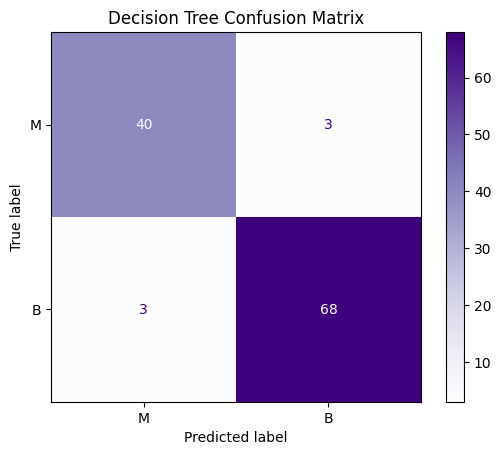

In [62]:
# Train Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=4)
dt_clf.fit(X_train, Y_train)
y_pred_dt = dt_clf.predict(X_test)

# Calculate Metrics
sensitivity_dt = recall_score(Y_test, y_pred_dt, pos_label='M')
specificity_dt = recall_score(Y_test, y_pred_dt, pos_label='B')
precision_dt = precision_score(Y_test, y_pred_dt, pos_label='M')
recall_dt = sensitivity_dt
accuracy_dt = accuracy_score(Y_test, y_pred_dt)

print(f"Decision Tree Metrics (Positive: M):")
print(f"- Accuracy: {accuracy_dt:.4f}")
print(f"- Sensitivity (Recall): {sensitivity_dt:.4f}")
print(f"- Specificity: {specificity_dt:.4f}")
print(f"- Precision: {precision_dt:.4f}")

# Confusion Matrix
cm_dt = confusion_matrix(Y_test, y_pred_dt, labels=labels)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=labels)
disp_dt.plot(cmap=plt.cm.Purples)
plt.title('Decision Tree Confusion Matrix')
plt.show()

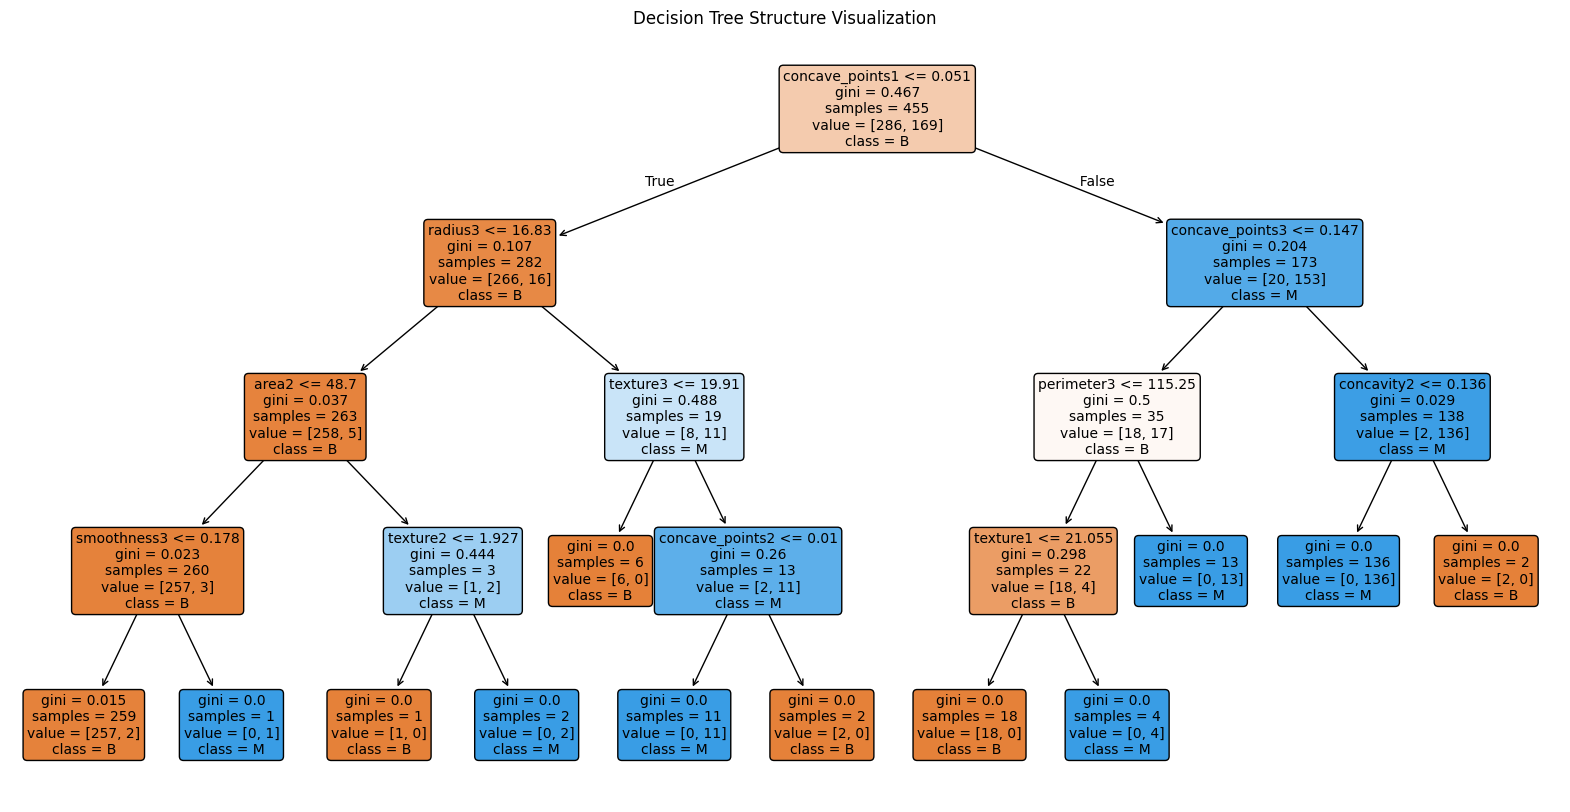

In [63]:
# Decision Tree Visualization
plt.figure(figsize=(20, 10))
plot_tree(dt_clf,
          feature_names=X.columns.tolist(),
          class_names=['B', 'M'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree Structure Visualization')
plt.show()

### 5. ROC Curve Comparison
In this section, we compare the performance of our models using the Receiver Operating Characteristic (ROC) curve and calculate the Area Under the Curve (AUC). Note: For OneR, since it is a rule-based classifier based on a single threshold, its ROC 'curve' consists of the point representing its specific rule.

In [2]:
from sklearn.metrics import roc_curve, auc
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import numpy as np

# Ensure models are trained (handling potential session resets)
# Re-training quickly to ensure variables exist
nb_clf = GaussianNB().fit(X_train, Y_train)
# Data scaling was done previously: X_train_scaled, X_test_scaled
lr_clf = LogisticRegression(max_iter=10000).fit(X_train_scaled, Y_train)
knn_clf = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, Y_train)
dt_clf = DecisionTreeClassifier(random_state=42, max_depth=4).fit(X_train, Y_train)

# Identify indices
m_idx_nb = list(nb_clf.classes_).index('M')
m_idx_lr = list(lr_clf.classes_).index('M')
m_idx_knn = list(knn_clf.classes_).index('M')
m_idx_dt = list(dt_clf.classes_).index('M')

plt.figure(figsize=(10, 8))

def plot_roc_standardized(fpr, tpr, label):
    # Explicitly ensure the curve starts at 0,0 and ends at 1,1
    fpr_fixed = np.concatenate([[0], fpr, [1]])
    tpr_fixed = np.concatenate([[0], tpr, [1]])
    roc_auc = auc(fpr_fixed, tpr_fixed)
    plt.plot(fpr_fixed, tpr_fixed, label=f"{label} (AUC = {roc_auc:.3f})")

# 1. Logistic Regression
y_score_lr = lr_clf.predict_proba(X_test_scaled)[:, m_idx_lr]
fpr_lr, tpr_lr, _ = roc_curve(Y_test, y_score_lr, pos_label='M')
plot_roc_standardized(fpr_lr, tpr_lr, 'Logistic Regression')

# 2. Naive Bayes
y_score_nb = nb_clf.predict_proba(X_test)[:, m_idx_nb]
fpr_nb, tpr_nb, _ = roc_curve(Y_test, y_score_nb, pos_label='M')
plot_roc_standardized(fpr_nb, tpr_nb, 'Naive Bayes')

# 3. KNN
y_score_knn = knn_clf.predict_proba(X_test_scaled)[:, m_idx_knn]
fpr_knn, tpr_knn, _ = roc_curve(Y_test, y_score_knn, pos_label='M')
plot_roc_standardized(fpr_knn, tpr_knn, 'KNN')

# 4. Decision Tree
y_score_dt = dt_clf.predict_proba(X_test)[:, m_idx_dt]
fpr_dt, tpr_dt, _ = roc_curve(Y_test, y_score_dt, pos_label='M')
plot_roc_standardized(fpr_dt, tpr_dt, 'Decision Tree')

# 5. OneR (Single Point)
# cm_oner from previous results
tp_oner, fn_oner = cm_oner[0, 0], cm_oner[0, 1]
fp_oner, tn_oner = cm_oner[1, 0], cm_oner[1, 1]
sens_oner = tp_oner / (tp_oner + fn_oner)
spec_oner = tn_oner / (fp_oner + tn_oner)
plt.plot(1 - spec_oner, sens_oner, 'ro', markersize=10, label=f'OneR Point (Sens={sens_oner:.2f}, Spec={spec_oner:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Final ROC Comparison (Anchored at Origin)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

NameError: name 'GaussianNB' is not defined